# Data exploration — Synthea lab observations

Raw data: `data/raw/observations.csv` (one row per observation) and `data/raw/patients.csv`.
The model input is one **lab panel per encounter**, so the raw rows are first explored as they are and then
pivoted into one row per encounter, using the same filters as `src/data/dataset_builder.py`.

In [1]:
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("../src/data")
from dataset_builder import CODE_TO_PARAM
from range_checker import RangeChecker

obs = pd.read_csv("../data/raw/observations.csv")
patients = pd.read_csv("../data/raw/patients.csv")

display(obs.head())

print("Shape:", obs.shape)

print("\n--- Info ---")
obs.info()

print("\n--- Summary statistics ---")
display(obs.describe(include="all"))

,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2018-01-22T08:35:36Z,cc3eac4a-34a7-9a15-1522-8087135631b7,cc3eac4a-34a7-9a15-da83-de2c625ae978,laboratory,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,6.3,%,numeric
1,2018-01-22T08:35:36Z,cc3eac4a-34a7-9a15-1522-8087135631b7,cc3eac4a-34a7-9a15-da83-de2c625ae978,vital-signs,8302-2,Body Height,182.1,cm,numeric
2,2018-01-22T08:35:36Z,cc3eac4a-34a7-9a15-1522-8087135631b7,cc3eac4a-34a7-9a15-da83-de2c625ae978,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,3.0,{score},numeric
3,2018-01-22T08:35:36Z,cc3eac4a-34a7-9a15-1522-8087135631b7,cc3eac4a-34a7-9a15-da83-de2c625ae978,vital-signs,29463-7,Body Weight,97.6,kg,numeric
4,2018-01-22T08:35:36Z,cc3eac4a-34a7-9a15-1522-8087135631b7,cc3eac4a-34a7-9a15-da83-de2c625ae978,vital-signs,39156-5,Body mass index (BMI) [Ratio],29.4,kg/m2,numeric


Shape: (68648, 9)

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 68648 entries, 0 to 68647
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   DATE         68648 non-null  str  
 1   PATIENT      68648 non-null  str  
 2   ENCOUNTER    65588 non-null  str  
 3   CATEGORY     65588 non-null  str  
 4   CODE         68648 non-null  str  
 5   DESCRIPTION  68648 non-null  str  
 6   VALUE        68648 non-null  str  
 7   UNITS        49768 non-null  str  
 8   TYPE         68648 non-null  str  
dtypes: str(9)
memory usage: 15.6 MB

--- Summary statistics ---


,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
count,68648,68648,65588,65588,68648,68648,68648,49768,68648
unique,6972,108,2535,8,243,244,3077,47,2
top,2024-01-11T20:04:51Z,bca1691f-8839-1d66-ed01-471134d55738,fb56f051-a2cd-ac10-76ef-13959deae12a,laboratory,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,No,mg/dL,numeric
freq,61,12118,684,29859,1808,1808,6533,9969,42531


In [2]:
display(patients.head())

print("Shape:", patients.shape)

print("\n--- Info ---")
patients.info()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,cc3eac4a-34a7-9a15-1522-8087135631b7,1978-01-16,NaN,999-55-9547,S99974479,X81842955X,Mr.,Guillermo498,NaN,VonRueden376,...,North Brookfield,Massachusetts,Worcester County,25027.0,1535,42.267480,-72.105242,104532.20,18048.65,42283
1,8b9df7af-24b3-66ee-afeb-2734ebcbd33c,2001-02-11,NaN,999-32-1995,S99911042,X98255942X,Ms.,Jayne73,Mira443,Bruen238,...,Bedford,Massachusetts,Middlesex County,25017.0,1730,42.539821,-71.256841,98009.84,531508.43,33657
2,65cbad6a-eb9d-420e-9bab-b4f9c6aab7db,1948-06-15,NaN,999-23-9791,S99928100,X83081075X,Mrs.,Grisel924,Dortha70,Balistreri607,...,Quincy,Massachusetts,Norfolk County,25021.0,2170,42.204748,-70.988341,796732.91,219824.56,64779
3,9a3814bb-f5b0-05f3-928e-fe6640d5aa2a,2015-07-19,NaN,999-56-4831,NaN,NaN,NaN,Esperanza675,Rachell479,Auer97,...,Taunton,Massachusetts,Bristol County,25005.0,2718,41.902707,-70.976300,44050.63,17747.77,34422
4,6a703775-432b-ba7d-d53a-c4d7bb0f5b58,1995-01-23,NaN,999-91-2539,S99931120,X52632004X,Mr.,Arnulfo253,NaN,Boyer713,...,Boston,Massachusetts,Suffolk County,25025.0,2116,42.359644,-71.079948,5450.00,97459.94,6565


Shape: (108, 28)

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   108 non-null    str    
 1   BIRTHDATE            108 non-null    str    
 2   DEATHDATE            9 non-null      str    
 3   SSN                  108 non-null    str    
 4   DRIVERS              89 non-null     str    
 5   PASSPORT             80 non-null     str    
 6   PREFIX               86 non-null     str    
 7   FIRST                108 non-null    str    
 8   MIDDLE               85 non-null     str    
 9   LAST                 108 non-null    str    
 10  SUFFIX               1 non-null      str    
 11  MAIDEN               20 non-null     str    
 12  MARITAL              69 non-null     str    
 13  RACE                 108 non-null    str    
 14  ETHNICITY            108 non-null    str    
 15  GENDER              

In [3]:
missing = obs.isna().sum().to_frame("missing")

missing["missing_percent"] = missing["missing"] / len(obs) * 100

missing = missing.sort_values("missing_percent", ascending=False)

display(missing)

,missing,missing_percent
UNITS,18880,27.502622
CATEGORY,3060,4.457522
ENCOUNTER,3060,4.457522
DATE,0,0.000000
PATIENT,0,0.000000
CODE,0,0.000000
DESCRIPTION,0,0.000000
VALUE,0,0.000000
TYPE,0,0.000000


In [4]:
for column in ["CATEGORY", "TYPE"]:
    print(f"\n--- {column} ---")
    print(obs[column].value_counts(dropna=False))

print("\n--- GENDER ---")
print(patients["GENDER"].value_counts(dropna=False))


--- CATEGORY ---
CATEGORY
laboratory        29859
survey            21642
vital-signs       12443
NaN                3060
social-history     1360
exam                211
imaging              46
procedure            22
therapy               5
Name: count, dtype: int64

--- TYPE ---
TYPE
numeric    42531
text       26117
Name: count, dtype: int64

--- GENDER ---
GENDER
M    57
F    51
Name: count, dtype: int64


In [5]:
# which rows have no ENCOUNTER / CATEGORY? they cannot be grouped into a lab panel
obs[obs["ENCOUNTER"].isna()]["DESCRIPTION"].value_counts().head(10)

DESCRIPTION
QALY    1020
DALY    1020
QOLS    1020
Name: count, dtype: int64

## Laboratory parameters in scope

Only the LOINC codes in `CODE_TO_PARAM` have a reference range in `config/reference_ranges.csv`.

In [6]:
lab = obs[obs["CODE"].isin(CODE_TO_PARAM.keys())].copy()
lab["parameter"] = lab["CODE"].map(CODE_TO_PARAM)
lab["value"] = pd.to_numeric(lab["VALUE"], errors="coerce")

print("Lab rows in scope:", len(lab), "of", len(obs))
print("Non-numeric values:", lab["value"].isna().sum())
print("Rows without encounter:", lab["ENCOUNTER"].isna().sum())

coverage = lab.groupby("parameter").agg(
    records=("value", "count"),
    patients=("PATIENT", "nunique"),
    units=("UNITS", lambda s: ", ".join(sorted(s.dropna().unique()))),
)
coverage["patient_coverage_percent"] = coverage["patients"] / patients["Id"].nunique() * 100

display(coverage.sort_values("records", ascending=False))

Lab rows in scope: 11641 of 68648
Non-numeric values: 0
Rows without encounter: 0


,records,patients,units,patient_coverage_percent
parameter,,,,
Calcium,1265,46,mg/dL,42.592593
Urea Nitrogen,1265,46,mg/dL,42.592593
Carbon Dioxide,1265,46,mmol/L,42.592593
Chloride,1265,46,mmol/L,42.592593
Glucose,1265,46,mg/dL,42.592593
Sodium,1265,46,mmol/L,42.592593
Potassium,1265,46,mmol/L,42.592593
HbA1c,720,39,%,36.111111
Platelets,296,108,10*3/uL,100.000000


## One row per encounter

Same filters as `dataset_builder.py`:
- adults only (age at encounter >= 18)
- drop encounters where one parameter has several different values (several visits merged)
- drop impossible HbA1c values (< 3.5 %), value-level

In [7]:
lab = lab.dropna(subset=["value", "ENCOUNTER"])
lab = lab.merge(
    patients[["Id", "GENDER", "BIRTHDATE"]], left_on="PATIENT", right_on="Id", how="left"
)

meta = lab.groupby("ENCOUNTER").agg(
    patient=("PATIENT", "first"),
    date=("DATE", "first"),
    gender=("GENDER", "first"),
    birthdate=("BIRTHDATE", "first"),
)
meta["age"] = meta["date"].str[:4].astype(int) - meta["birthdate"].str[:4].astype(int)
meta = meta.drop(columns="birthdate")

print("Encounters with in-scope labs:", len(meta))

pediatric = meta.index[meta["age"] < 18]
print("Pediatric encounters (< 18):", len(pediatric))
lab = lab[~lab["ENCOUNTER"].isin(pediatric)]

distinct_values = lab.groupby(["ENCOUNTER", "parameter"])["value"].nunique()
misaligned = distinct_values[distinct_values > 1].index.get_level_values("ENCOUNTER").unique()
print("Misaligned encounters:", len(misaligned))
lab = lab[~lab["ENCOUNTER"].isin(misaligned)]

impossible_hba1c = (lab["parameter"] == "HbA1c") & (lab["value"] < 3.5)
print("Impossible HbA1c values:", impossible_hba1c.sum())
lab = lab[~impossible_hba1c]

panel = lab.pivot_table(index="ENCOUNTER", columns="parameter", values="value", aggfunc="first")
lab_columns = panel.columns.tolist()

df = meta.join(panel, how="inner").reset_index()

display(df.head())

print("Shape:", df.shape)

print("\n--- Info ---")
df.info()

print("\n--- Summary statistics ---")
display(df.describe())

Encounters with in-scope labs: 1056
Pediatric encounters (< 18): 59
Misaligned encounters: 10
Impossible HbA1c values: 282


,ENCOUNTER,patient,date,gender,age,ALT,Calcium,Carbon Dioxide,Chloride,Erythrocytes,...,HbA1c,Hematocrit,Hemoglobin,Leukocytes,MCV,Platelets,Potassium,Sodium,TSH,Urea Nitrogen
0,00bcbfc6-c7b9-bd0e-0fe2-db4de2617b51,00bcbfc6-c7b9-bd0e-3d95-071f9fba6321,2020-05-26T01:16:49Z,F,39,NaN,8.8,22.3,110.2,NaN,...,5.9,NaN,NaN,NaN,NaN,NaN,4.4,136.9,NaN,11.1
1,00bcbfc6-c7b9-bd0e-1c1e-c72a7208dbd4,00bcbfc6-c7b9-bd0e-3d95-071f9fba6321,2018-05-15T01:16:49Z,F,37,NaN,8.5,21.7,105.6,NaN,...,6.2,NaN,NaN,NaN,NaN,NaN,4.2,136.7,NaN,17.4
2,00bcbfc6-c7b9-bd0e-2ca3-dc72c56e2fcc,00bcbfc6-c7b9-bd0e-3d95-071f9fba6321,2025-06-24T01:16:49Z,F,44,NaN,8.9,26.5,103.4,NaN,...,6.1,NaN,NaN,NaN,NaN,NaN,3.8,138.9,NaN,15.3
3,00bcbfc6-c7b9-bd0e-6913-8eaabfdacaa6,00bcbfc6-c7b9-bd0e-3d95-071f9fba6321,2023-06-13T01:16:49Z,F,42,NaN,9.7,21.6,107.6,NaN,...,6.2,NaN,NaN,NaN,NaN,NaN,4.4,139.9,NaN,8.6
4,00bcbfc6-c7b9-bd0e-8123-84ca497122bf,00bcbfc6-c7b9-bd0e-3d95-071f9fba6321,2019-05-21T01:16:49Z,F,38,NaN,9.0,25.4,104.3,5.1,...,5.9,36.3,12.6,9.4,86.3,435.8,4.6,137.9,NaN,8.9


Shape: (987, 22)

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 987 entries, 0 to 986
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ENCOUNTER       987 non-null    str    
 1   patient         987 non-null    str    
 2   date            987 non-null    str    
 3   gender          987 non-null    str    
 4   age             987 non-null    int64  
 5   ALT             182 non-null    float64
 6   Calcium         897 non-null    float64
 7   Carbon Dioxide  897 non-null    float64
 8   Chloride        897 non-null    float64
 9   Erythrocytes    164 non-null    float64
 10  Ferritin        6 non-null      float64
 11  Glucose         897 non-null    float64
 12  HbA1c           407 non-null    float64
 13  Hematocrit      155 non-null    float64
 14  Hemoglobin      164 non-null    float64
 15  Leukocytes      164 non-null    float64
 16  MCV             164 non-null    float64
 17  Platelets      

,age,ALT,Calcium,Carbon Dioxide,Chloride,Erythrocytes,Ferritin,Glucose,HbA1c,Hematocrit,Hemoglobin,Leukocytes,MCV,Platelets,Potassium,Sodium,TSH,Urea Nitrogen
count,987.000000,182.000000,897.000000,897.000000,897.000000,164.000000,6.000000,897.000000,407.000000,155.000000,164.000000,164.000000,164.000000,164.000000,897.000000,897.000000,2.000000,897.000000
mean,56.331307,38.460989,9.342809,24.542140,106.035452,4.645732,88.383333,88.219844,5.443735,42.837419,14.426220,7.150000,87.776220,300.584146,4.444593,140.182609,3.850000,13.496433
std,16.743521,13.047862,0.486877,2.558269,2.860681,0.468564,28.490940,16.339319,0.948270,4.220792,1.910156,2.051141,4.657257,89.193845,0.447683,2.328456,1.343503,3.779912
min,19.000000,0.600000,8.500000,20.000000,101.000000,3.900000,49.600000,64.100000,4.000000,35.000000,7.100000,3.100000,80.200000,126.400000,3.700000,136.000000,2.900000,7.000000
25%,46.000000,28.775000,8.900000,22.300000,103.700000,4.200000,68.300000,74.300000,4.300000,39.250000,12.975000,5.500000,83.700000,223.025000,4.100000,138.200000,3.375000,10.200000
50%,53.000000,37.450000,9.300000,24.600000,106.100000,4.650000,90.300000,86.300000,5.900000,42.900000,14.300000,7.400000,88.400000,300.900000,4.400000,140.200000,3.850000,13.500000
75%,70.000000,49.075000,9.700000,26.700000,108.400000,5.100000,110.875000,98.400000,6.200000,46.750000,16.100000,8.800000,91.650000,381.825000,4.800000,142.200000,4.325000,16.700000
max,96.000000,59.600000,10.200000,29.000000,111.000000,5.700000,121.400000,124.700000,7.600000,49.900000,17.500000,10.400000,95.600000,444.600000,5.200000,144.000000,4.800000,20.000000


In [8]:
missing = df.isna().sum().to_frame("missing")

missing["missing_percent"] = missing["missing"] / len(df) * 100

missing = missing.sort_values("missing_percent", ascending=False)

display(missing)

,missing,missing_percent
TSH,985,99.797366
Ferritin,981,99.392097
Hematocrit,832,84.295846
Erythrocytes,823,83.383992
MCV,823,83.383992
Leukocytes,823,83.383992
Hemoglobin,823,83.383992
Platelets,823,83.383992
ALT,805,81.560284
HbA1c,580,58.763931


count    987.000000
mean       7.954407
std        2.057231
min        1.000000
25%        7.000000
50%        8.000000
75%        8.000000
max       16.000000
Name: lab_count, dtype: float64


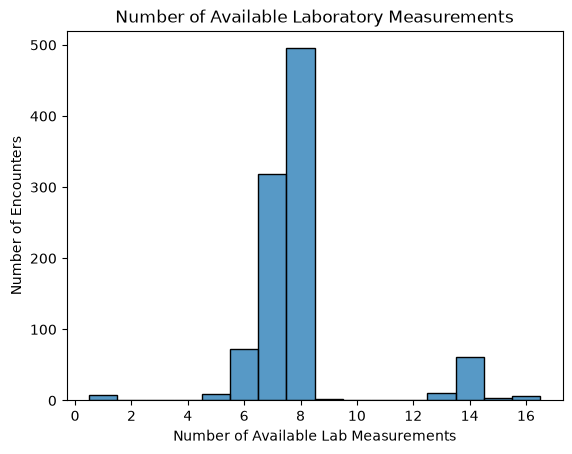

In [9]:
df["lab_count"] = df[lab_columns].notna().sum(axis=1)

print(df["lab_count"].describe())

sns.histplot(data=df, x="lab_count", discrete=True)

plt.title("Number of Available Laboratory Measurements")
plt.xlabel("Number of Available Lab Measurements")
plt.ylabel("Number of Encounters")
plt.show()

In [10]:
# which parameters are measured together? (panel types)
panel_types = (
    df[lab_columns]
    .notna()
    .apply(lambda row: ", ".join(row.index[row]), axis=1)
    .value_counts()
    .to_frame("encounters")
)

pd.set_option("display.max_colwidth", None)
display(panel_types.head(10))

,encounters
"Calcium, Carbon Dioxide, Chloride, Glucose, HbA1c, Potassium, Sodium, Urea Nitrogen",329
"Calcium, Carbon Dioxide, Chloride, Glucose, Potassium, Sodium, Urea Nitrogen",318
"ALT, Calcium, Carbon Dioxide, Chloride, Glucose, Potassium, Sodium, Urea Nitrogen",166
"Erythrocytes, Hematocrit, Hemoglobin, Leukocytes, MCV, Platelets",73
"Calcium, Carbon Dioxide, Chloride, Erythrocytes, Glucose, HbA1c, Hematocrit, Hemoglobin, Leukocytes, MCV, Platelets, Potassium, Sodium, Urea Nitrogen",58
"Calcium, Carbon Dioxide, Chloride, Erythrocytes, Glucose, Hematocrit, Hemoglobin, Leukocytes, MCV, Platelets, Potassium, Sodium, Urea Nitrogen",10
"Erythrocytes, Hemoglobin, Leukocytes, MCV, Platelets",9
HbA1c,8
"ALT, Calcium, Carbon Dioxide, Chloride, Erythrocytes, Ferritin, Glucose, HbA1c, Hematocrit, Hemoglobin, Leukocytes, MCV, Platelets, Potassium, Sodium, Urea Nitrogen",6
"ALT, Calcium, Carbon Dioxide, Chloride, Erythrocytes, Glucose, HbA1c, Hematocrit, Hemoglobin, Leukocytes, MCV, Platelets, Potassium, Sodium, Urea Nitrogen",3


count     78.000000
mean      12.653846
std       30.871256
min        1.000000
25%        2.000000
50%        4.500000
75%       11.000000
max      220.000000
dtype: float64


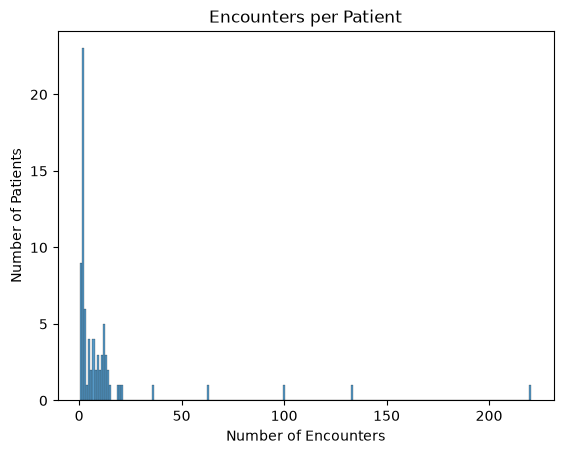

In [11]:
encounters_per_patient = df.groupby("patient").size()

print(encounters_per_patient.describe())

sns.histplot(encounters_per_patient, discrete=True)

plt.title("Encounters per Patient")
plt.xlabel("Number of Encounters")
plt.ylabel("Number of Patients")
plt.show()

## Target

A value is flagged `Low` / `High` against `config/reference_ranges.csv` (gender-specific where available).
An encounter is **abnormal** when at least one parameter is flagged.

In [12]:
checker = RangeChecker(ref_file="../config/reference_ranges.csv")

flags = pd.DataFrame(index=df.index, columns=lab_columns, dtype="object")

for column in lab_columns:
    measured = df[column].notna()
    flags.loc[measured, column] = [
        checker.evaluate(column, value, gender=gender, age=age)
        for value, gender, age in zip(
            df.loc[measured, column], df.loc[measured, "gender"], df.loc[measured, "age"]
        )
    ]

df["abnormal_count"] = flags.isin(["Low", "High"]).sum(axis=1)
df["has_abnormal"] = (df["abnormal_count"] > 0).astype(int)

print("--- has_abnormal ---")
print(df["has_abnormal"].value_counts(dropna=False))
print(df["has_abnormal"].value_counts(normalize=True))

print("\n--- abnormal_count ---")
print(df["abnormal_count"].value_counts().sort_index())

--- has_abnormal ---
has_abnormal
1    860
0    127
Name: count, dtype: int64
has_abnormal
1    0.871327
0    0.128673
Name: proportion, dtype: float64

--- abnormal_count ---
abnormal_count
0    127
1    345
2    312
3    146
4     40
5     14
6      2
7      1
Name: count, dtype: int64


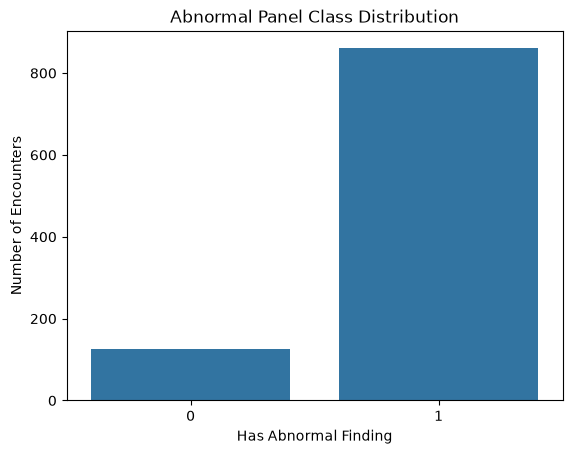

In [13]:
sns.countplot(data=df, x="has_abnormal")

plt.title("Abnormal Panel Class Distribution")
plt.xlabel("Has Abnormal Finding")
plt.ylabel("Number of Encounters")

plt.show()

In [14]:
flag_summary = pd.DataFrame(
    {
        "measured": flags.notna().sum(),
        "low": (flags == "Low").sum(),
        "high": (flags == "High").sum(),
    }
)
flag_summary["abnormal_percent"] = (
    (flag_summary["low"] + flag_summary["high"]) / flag_summary["measured"] * 100
)

display(flag_summary.sort_values("abnormal_percent", ascending=False))

,measured,low,high,abnormal_percent
HbA1c,407,0,261,64.127764
Chloride,897,0,452,50.390190
TSH,2,0,1,50.000000
Hemoglobin,164,42,31,44.512195
Glucose,897,135,211,38.573021
Hematocrit,155,42,10,33.548387
Erythrocytes,164,28,24,31.707317
Carbon Dioxide,897,284,0,31.661093
ALT,182,4,16,10.989011
Potassium,897,0,96,10.702341


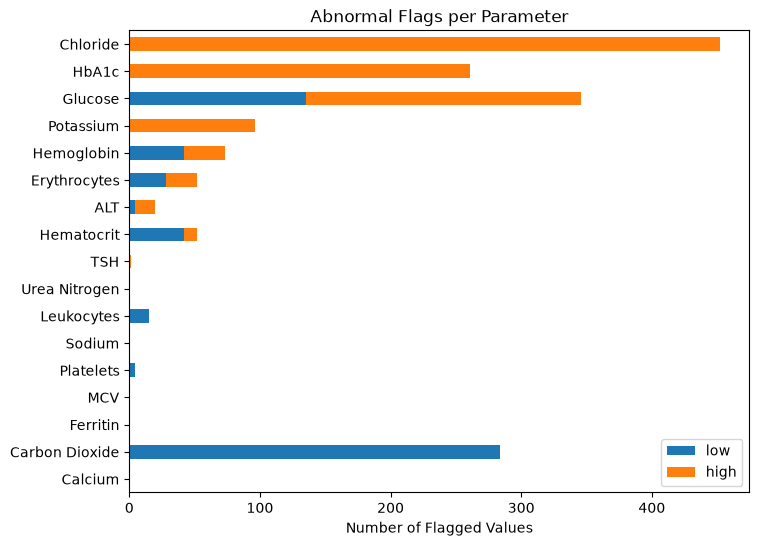

In [15]:
flag_summary[["low", "high"]].sort_values("high").plot(kind="barh", stacked=True, figsize=(8, 6))

plt.title("Abnormal Flags per Parameter")
plt.xlabel("Number of Flagged Values")
plt.ylabel("")
plt.show()

        count      mean
gender                 
F         191  0.931937
M         796  0.856784


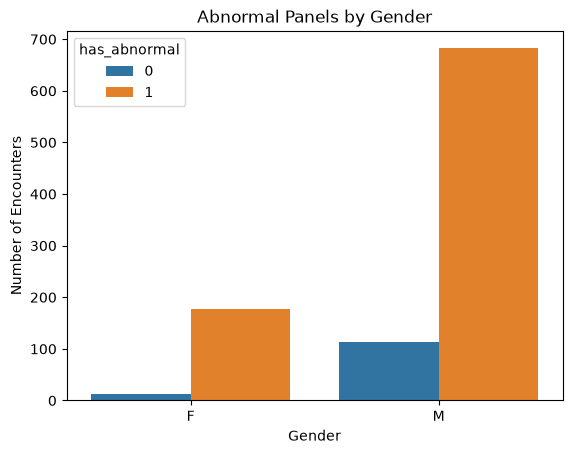

In [16]:
print(df.groupby("gender")["has_abnormal"].agg(["count", "mean"]))

sns.countplot(data=df, x="gender", hue="has_abnormal")

plt.title("Abnormal Panels by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Encounters")
plt.show()

## Distributions

In [17]:
df[["age"] + lab_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,987.0,56.331307,16.743521,19.0,46.000,53.00,70.000,96.0
ALT,182.0,38.460989,13.047862,0.6,28.775,37.45,49.075,59.6
Calcium,897.0,9.342809,0.486877,8.5,8.900,9.30,9.700,10.2
Carbon Dioxide,897.0,24.542140,2.558269,20.0,22.300,24.60,26.700,29.0
Chloride,897.0,106.035452,2.860681,101.0,103.700,106.10,108.400,111.0
Erythrocytes,164.0,4.645732,0.468564,3.9,4.200,4.65,5.100,5.7
Ferritin,6.0,88.383333,28.490940,49.6,68.300,90.30,110.875,121.4
Glucose,897.0,88.219844,16.339319,64.1,74.300,86.30,98.400,124.7
HbA1c,407.0,5.443735,0.948270,4.0,4.300,5.90,6.200,7.6
Hematocrit,155.0,42.837419,4.220792,35.0,39.250,42.90,46.750,49.9


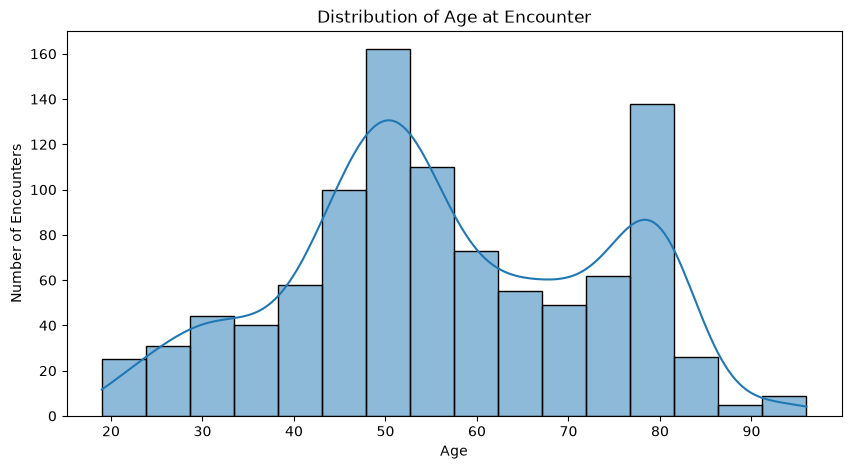

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="age", kde=True)

plt.title("Distribution of Age at Encounter")
plt.xlabel("Age")
plt.ylabel("Number of Encounters")

plt.show()

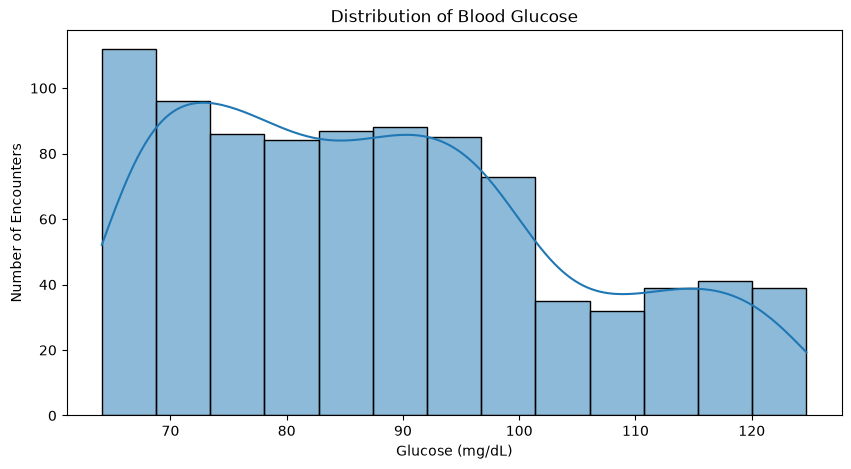

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="Glucose", kde=True)

plt.title("Distribution of Blood Glucose")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Number of Encounters")

plt.show()

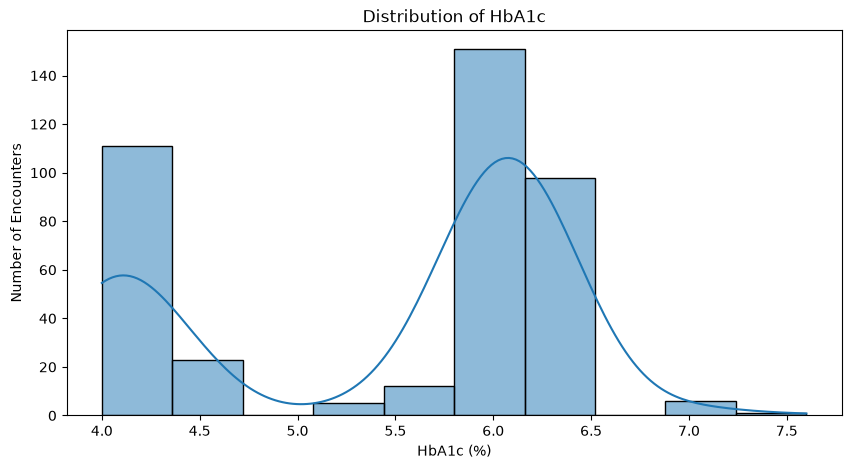

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="HbA1c", kde=True)

plt.title("Distribution of HbA1c")
plt.xlabel("HbA1c (%)")
plt.ylabel("Number of Encounters")

plt.show()

In [21]:
negative_validation_checks = {
    "age": df["age"] < 0,
    "age > 120": df["age"] > 120,
    "Glucose": df["Glucose"] <= 0,
    "HbA1c": df["HbA1c"] <= 0,
    "Sodium": df["Sodium"] <= 0,
    "Potassium": df["Potassium"] <= 0,
    "Hemoglobin": df["Hemoglobin"] <= 0,
}

for column, condition in negative_validation_checks.items():
    print(f"{column}: {condition.sum()} invalid values")

age: 0 invalid values
age > 120: 0 invalid values
Glucose: 0 invalid values
HbA1c: 0 invalid values
Sodium: 0 invalid values
Potassium: 0 invalid values
Hemoglobin: 0 invalid values


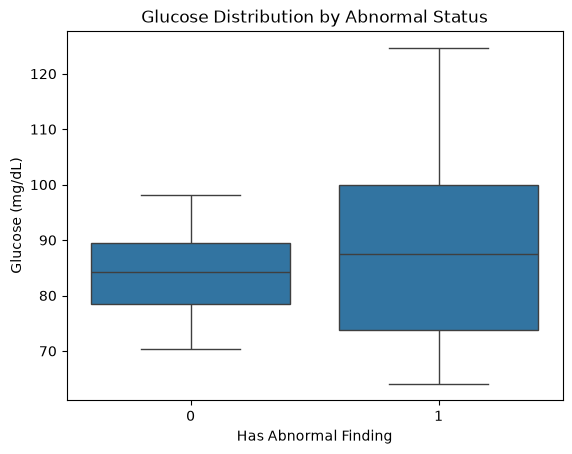

In [22]:
sns.boxplot(data=df, x="has_abnormal", y="Glucose")

plt.title("Glucose Distribution by Abnormal Status")
plt.xlabel("Has Abnormal Finding")
plt.ylabel("Glucose (mg/dL)")
plt.show()

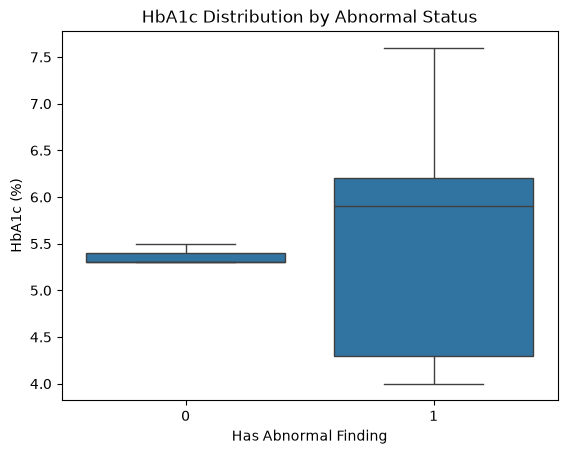

In [23]:
sns.boxplot(data=df, x="has_abnormal", y="HbA1c")

plt.title("HbA1c Distribution by Abnormal Status")
plt.xlabel("Has Abnormal Finding")
plt.ylabel("HbA1c (%)")
plt.show()

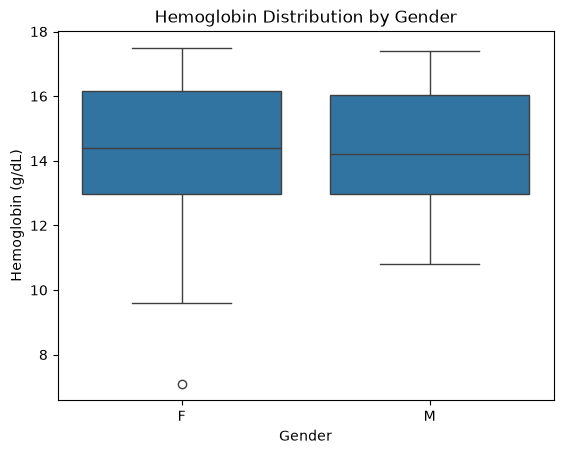

In [24]:
# Hemoglobin has gender-specific reference ranges
sns.boxplot(data=df, x="gender", y="Hemoglobin")

plt.title("Hemoglobin Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Hemoglobin (g/dL)")
plt.show()

## Extreme values and outliers

In [25]:
extreme_columns = [
    "Glucose",
    "HbA1c",
    "Urea Nitrogen",
    "Sodium",
    "Potassium",
    "Chloride",
    "Calcium",
    "Carbon Dioxide",
    "Hemoglobin",
    "Leukocytes",
    "Platelets",
    "ALT",
]

for column in extreme_columns:
    print(f"\n===== {column} =====")
    display(
        df[["patient", "age", "gender", column]]
        .dropna(subset=[column])
        .sort_values(column, ascending=False)
        .head(10)
    )


===== Glucose =====


,patient,age,gender,Glucose
456,57efda89-b582-bb08-8a2d-e06b2c184bfc,44,M,124.7
211,355a4d50-2628-aa65-c336-deacf4d606fb,66,M,124.7
499,57efda89-b582-bb08-8a2d-e06b2c184bfc,49,M,124.5
419,57efda89-b582-bb08-8a2d-e06b2c184bfc,47,M,124.4
500,57efda89-b582-bb08-8a2d-e06b2c184bfc,51,M,124.4
533,57efda89-b582-bb08-8a2d-e06b2c184bfc,46,M,124.3
484,57efda89-b582-bb08-8a2d-e06b2c184bfc,50,M,123.9
509,57efda89-b582-bb08-8a2d-e06b2c184bfc,47,M,123.8
519,57efda89-b582-bb08-8a2d-e06b2c184bfc,46,M,123.6
168,355a4d50-2628-aa65-c336-deacf4d606fb,66,M,123.6



===== HbA1c =====


,patient,age,gender,HbA1c
79,1be83f06-48ef-7bac-7097-b9e0644aeaf8,46,M,7.6
216,355a4d50-2628-aa65-c336-deacf4d606fb,60,M,7.0
187,355a4d50-2628-aa65-c336-deacf4d606fb,64,M,7.0
191,355a4d50-2628-aa65-c336-deacf4d606fb,65,M,7.0
221,355a4d50-2628-aa65-c336-deacf4d606fb,61,M,7.0
229,355a4d50-2628-aa65-c336-deacf4d606fb,62,M,7.0
214,355a4d50-2628-aa65-c336-deacf4d606fb,65,M,7.0
101,2211f478-b7b4-7711-16cf-84ffb52b9d2b,27,F,6.4
110,2211f478-b7b4-7711-16cf-84ffb52b9d2b,28,F,6.4
955,f67eaca3-2366-7ee2-6887-a5bd449b54a6,31,M,6.4



===== Urea Nitrogen =====


...

,patient,age,gender,Leukocytes
605,8d91c36a-1f7e-3842-9f14-8d567ed9cdcd,34,M,10.4
538,5dae1e9e-46fb-5537-54f4-8837a56dd3d5,28,M,10.4
112,2211f478-b7b4-7711-16cf-84ffb52b9d2b,32,F,10.3
124,23da8e71-dfb9-9773-1bc1-7b5e31d085b5,62,M,10.3
624,a406f356-c8b4-54ad-e79c-54a5e15ffc19,30,M,10.3
956,f67eaca3-2366-7ee2-6887-a5bd449b54a6,34,M,10.3
640,ad48e669-959c-b6f8-8ddb-dda7a6d37473,23,F,10.2
539,6095681c-dfc1-8f20-411c-42cef37189fa,22,M,10.2
290,46fcc34a-97a1-f038-9bb1-4ae87116ae61,33,F,10.2
565,72b1ca95-c4f0-269d-28bf-ba36b25a9aa6,28,F,10.1



===== Platelets =====


,patient,age,gender,Platelets
922,e7c068bb-6d29-27d3-0b8b-ec0406cc91b7,26,F,444.6
541,65cbad6a-eb9d-420e-9bab-b4f9c6aab7db,76,F,444.5
164,3314e296-2326-2826-271d-a7be5b896db9,28,F,443.9
587,8704c44c-8b97-e35a-3bac-7d5b24de06b3,28,F,443.6
913,e170fdcd-8830-89c4-94b2-aaf7f35ca9c5,35,F,442.9
93,1d63466e-0cfd-eb12-77aa-d153393355e5,62,M,440.7
599,8d91c36a-1f7e-3842-9f14-8d567ed9cdcd,34,M,436.5
883,ca443842-f546-d34c-a69b-b044cfe007d9,39,F,435.9
4,00bcbfc6-c7b9-bd0e-3d95-071f9fba6321,38,F,435.8
245,3732fde5-efc6-d57a-517b-0500f2177181,66,M,435.8



===== ALT =====


,patient,age,gender,ALT
700,bca1691f-8839-1d66-ed01-471134d55738,81,M,59.6
97,1d63466e-0cfd-eb12-77aa-d153393355e5,63,M,59.4
833,bca1691f-8839-1d66-ed01-471134d55738,79,M,59.2
724,bca1691f-8839-1d66-ed01-471134d55738,79,M,58.7
238,3732fde5-efc6-d57a-517b-0500f2177181,66,M,58.3
272,3c0e60c4-176e-2c4c-3b85-b46be390cf5e,60,F,58.2
271,3c0e60c4-176e-2c4c-3b85-b46be390cf5e,61,F,58.1
98,1d63466e-0cfd-eb12-77aa-d153393355e5,66,M,57.8
508,57efda89-b582-bb08-8a2d-e06b2c184bfc,46,M,57.7
958,f870c432-0887-125e-f778-cf5110d3de1d,52,M,57.5


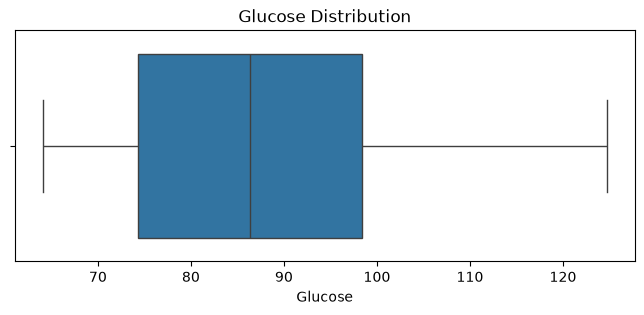

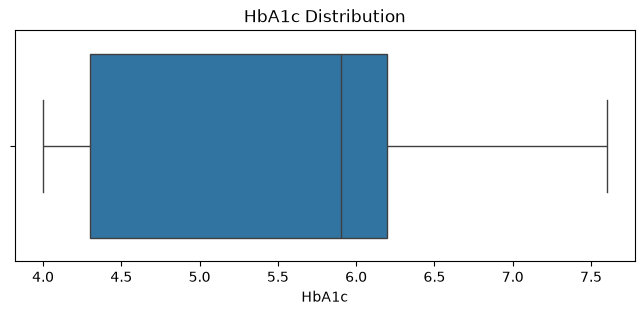

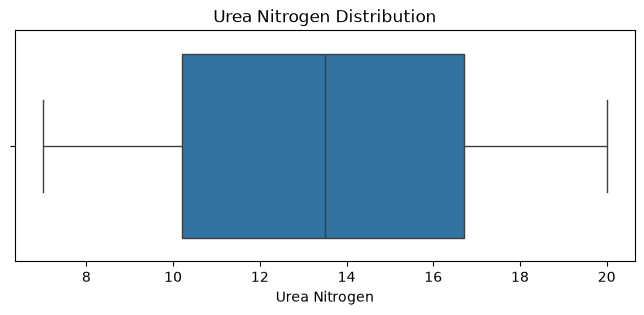

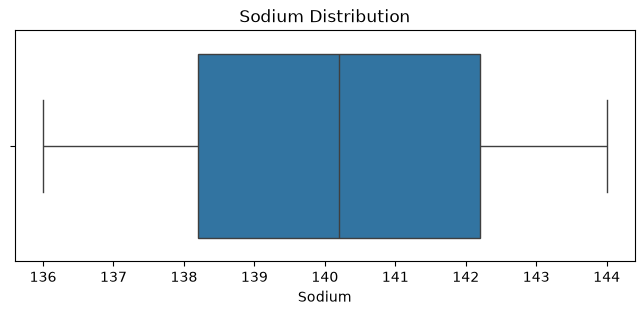

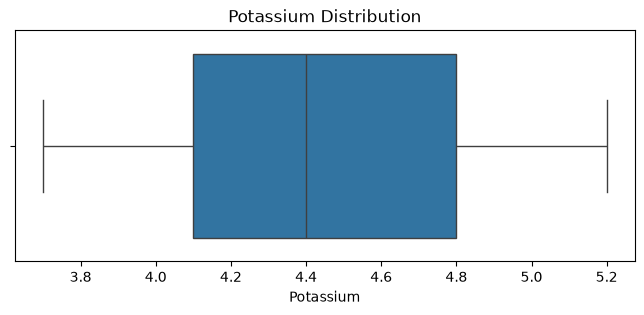

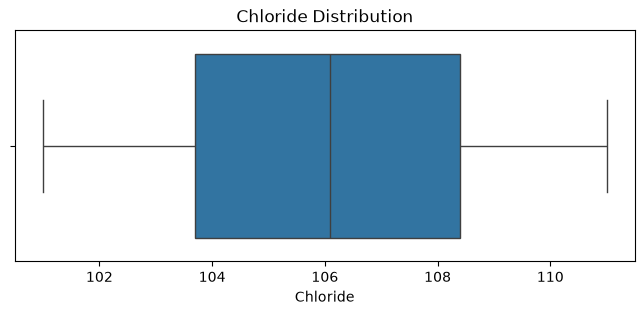

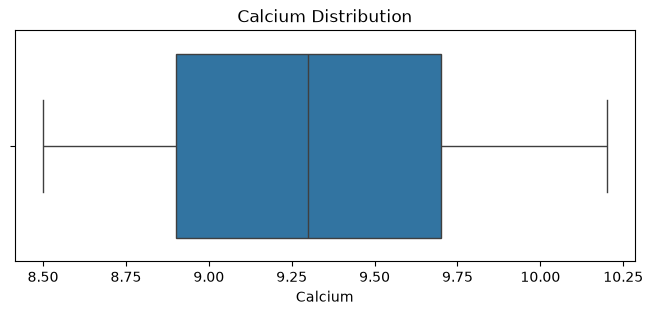

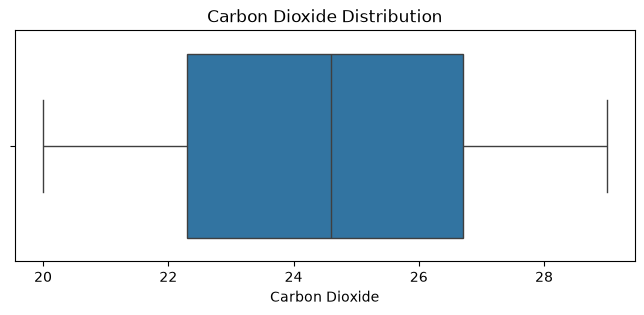

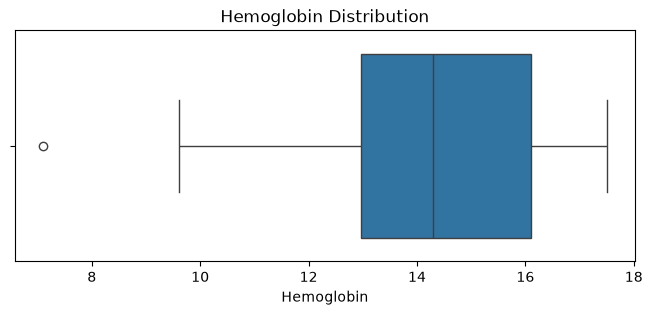

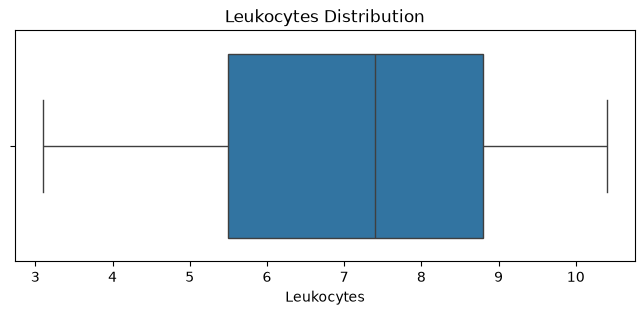

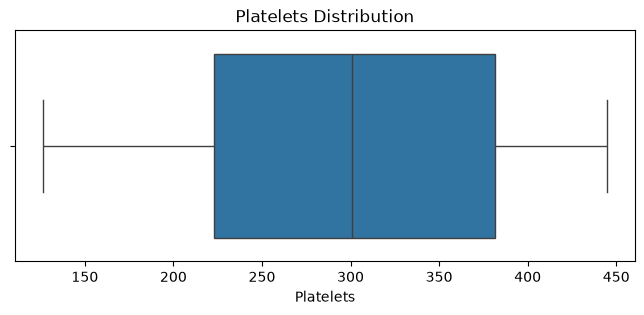

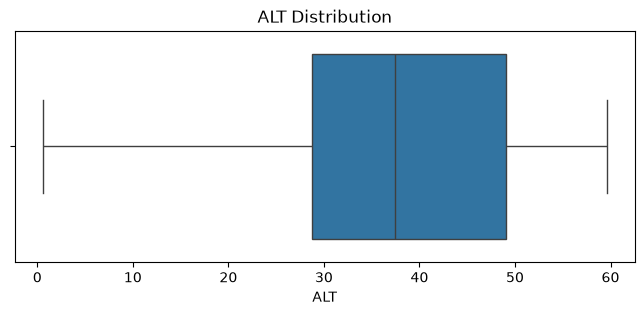

In [26]:
for column in extreme_columns:
    plt.figure(figsize=(8, 3))

    sns.boxplot(data=df, x=column)

    plt.title(f"{column} Distribution")
    plt.xlabel(column)

    plt.show()

In [27]:
reference = pd.read_csv("../config/reference_ranges.csv")
reference = reference[reference["gender"] == "all"].set_index("parameter")

for column in extreme_columns:
    series = df[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = series[(series < lower) | (series > upper)]

    print(
        f"{column:16} "
        f"outliers={len(outliers):4} "
        f"lower={lower:7.2f} "
        f"upper={upper:7.2f} "
        f"reference={reference.loc[column, 'lower_bound']}-{reference.loc[column, 'upper_bound']}"
    )

Glucose          outliers=   0 lower=  38.15 upper= 134.55 reference=70.0-99.0
HbA1c            outliers=   0 lower=   1.45 upper=   9.05 reference=4.0-5.6
Urea Nitrogen    outliers=   0 lower=   0.45 upper=  26.45 reference=7.0-20.0
Sodium           outliers=   0 lower= 132.20 upper= 148.20 reference=135.0-145.0
Potassium        outliers=   0 lower=   3.05 upper=   5.85 reference=3.5-5.0
Chloride         outliers=   0 lower=  96.65 upper= 115.45 reference=96.0-106.0
Calcium          outliers=   0 lower=   7.70 upper=  10.90 reference=8.5-10.2
Carbon Dioxide   outliers=   0 lower=  15.70 upper=  33.30 reference=23.0-29.0
Hemoglobin       outliers=   1 lower=   8.29 upper=  20.79 reference=12.0-17.2
Leukocytes       outliers=   0 lower=   0.55 upper=  13.75 reference=4.0-11.0
Platelets        outliers=   0 lower= -15.18 upper= 620.03 reference=150.0-450.0
ALT              outliers=   0 lower=  -1.68 upper=  79.53 reference=7.0-56.0


              count      mean       std  min  25%  50%  75%   max
has_abnormal                                                     
0             127.0  7.086614  0.806950  6.0  7.0  7.0  7.0  13.0
1             860.0  8.082558  2.152817  1.0  7.0  8.0  8.0  16.0


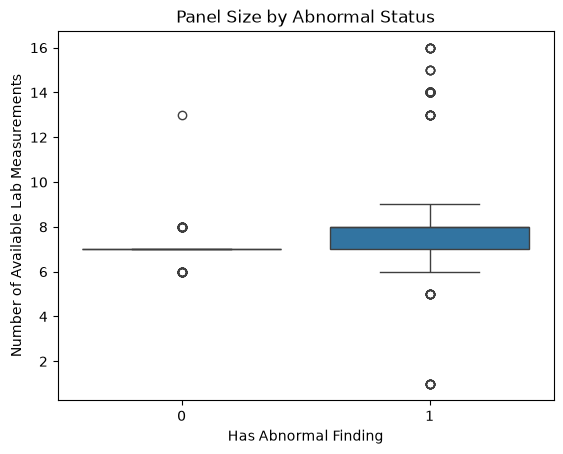

In [28]:
# normal panels: how many measurements do they contain?
print(df.groupby("has_abnormal")["lab_count"].describe())

sns.boxplot(data=df, x="has_abnormal", y="lab_count")

plt.title("Panel Size by Abnormal Status")
plt.xlabel("Has Abnormal Finding")
plt.ylabel("Number of Available Lab Measurements")
plt.show()

## Findings

### What the data looks like
- 68,648 observations for 108 patients; only 11,641 rows (17 parameters) have a reference range.
- `UNITS` is missing for 27.5 % of rows (text / survey observations) and 4.5 % have no `ENCOUNTER`
  (only QALY / DALY / QOLS scores) - none of these are lab values.
- After filtering: 987 encounters (59 pediatric and 10 misaligned encounters removed).
- 282 HbA1c values are below 3.5 % (impossible) - dropped at value level, the rest of the panel is kept.

### Target
- The data is skewed 87 % of the panels have at least one abnormal finding, so **normal is the rare class**.
- Abnormal findings come mostly from HbA1c, Chloride, Glucose and Carbon Dioxide.
  Calcium, Sodium, Urea Nitrogen, MCV and Ferritin are never abnormal.
- Glucose, Hemoglobin, Hematocrit and Erythrocytes are flagged both `Low` and `High`,
  and the Hemoglobin / Hematocrit / Erythrocytes ranges depend on gender.

### Synthetic data
- No negative or impossible values apart from HbA1c, and almost no IQR outliers:
  Synthea draws values from fixed ranges, so the extremes sit close to the reference bounds.